In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import Xception
from tensorflow.keras.preprocessing import image_dataset_from_directory

2025-03-25 01:16:54.270932: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-25 01:16:54.281651: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742883414.292282   79452 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742883414.295390   79452 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742883414.304238   79452 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
image_size = (299, 299)
batch_size = 32

train_ds = keras.utils.image_dataset_from_directory(
    "data/4_class_tumors/Training",
    image_size=image_size,
    batch_size=batch_size,
)

val_ds = keras.utils.image_dataset_from_directory(
    "data/4_class_tumors/Testing",
    image_size=image_size,
    batch_size=batch_size,
)

Found 5712 files belonging to 4 classes.


I0000 00:00:1742883417.215669   79452 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1211 MB memory:  -> device: 0, name: NVIDIA RTX A2000 12GB, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 1312 files belonging to 4 classes.


# MODEL - Xception Transfer Learning
https://www.tensorflow.org/api_docs/python/tf/keras/applications/Xception   

In [3]:
base_model = Xception(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # Freeze the base model

In [4]:
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax') 
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [5]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20


I0000 00:00:1742879335.600273   42909 service.cc:152] XLA service 0x7ad43003b580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742879335.600318   42909 service.cc:160]   StreamExecutor device (0): NVIDIA RTX A2000 12GB, Compute Capability 8.6
2025-03-25 00:08:55.695406: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742879336.135454   42909 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-03-25 00:08:56.719928: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6220', 20 bytes spill stores, 20 bytes spill loads

2025-03-25 00:08:56.918656: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4267', 

  1/179 ━━━━━━━━━━━━━━━━━━━━ 45:28 15s/step - accuracy: 0.1250 - loss: 6.2598

I0000 00:00:1742879349.393095   42909 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


178/179 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5584 - loss: 1.8940

2025-03-25 00:09:30.892612: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4267', 4 bytes spill stores, 4 bytes spill loads

2025-03-25 00:09:31.196055: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4267', 116 bytes spill stores, 116 bytes spill loads

2025-03-25 00:09:31.509475: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4267', 992 bytes spill stores, 992 bytes spill loads

2025-03-25 00:09:31.606629: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4267', 3940 bytes spill stores, 3920 bytes spill loads



179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5590 - loss: 1.8897

2025-03-25 00:09:39.590788: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1039', 4 bytes spill stores, 4 bytes spill loads

2025-03-25 00:09:45.586119: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1032', 4 bytes spill stores, 4 bytes spill loads

2025-03-25 00:09:45.682555: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1032', 8 bytes spill stores, 8 bytes spill loads

2025-03-25 00:09:45.716843: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1032', 220 bytes spill stores, 220 bytes spill loads

2025-03-25 00:09:45.986002: I external/local

179/179 ━━━━━━━━━━━━━━━━━━━━ 64s 274ms/step - accuracy: 0.5596 - loss: 1.8854 - val_accuracy: 0.7757 - val_loss: 0.6394
Epoch 2/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.7833 - loss: 0.5917 - val_accuracy: 0.8047 - val_loss: 0.4674
Epoch 3/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - accuracy: 0.7992 - loss: 0.5281 - val_accuracy: 0.8253 - val_loss: 0.4261
Epoch 4/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 26s 147ms/step - accuracy: 0.8253 - loss: 0.4552 - val_accuracy: 0.8528 - val_loss: 0.3784
Epoch 5/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 26s 148ms/step - accuracy: 0.8538 - loss: 0.3963 - val_accuracy: 0.8505 - val_loss: 0.3667
Epoch 6/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 27s 148ms/step - accuracy: 0.8524 - loss: 0.3883 - val_accuracy: 0.8612 - val_loss: 0.3530
Epoch 7/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 27s 149ms/step - accuracy: 0.8619 - loss: 0.3596 - val_accuracy: 0.8551 - val_loss: 0.3758
Epoch 8/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 27s 150ms/step - accuracy: 0.8733 - loss: 0.3462 - val

In [6]:
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20


2025-03-25 00:18:28.786229: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6538', 4 bytes spill stores, 4 bytes spill loads

2025-03-25 00:18:28.885923: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6538', 12 bytes spill stores, 16 bytes spill loads



179/179 ━━━━━━━━━━━━━━━━━━━━ 56s 252ms/step - accuracy: 0.4979 - loss: 1.3005 - val_accuracy: 0.6102 - val_loss: 1.0309
Epoch 2/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 37s 207ms/step - accuracy: 0.7240 - loss: 0.7385 - val_accuracy: 0.7803 - val_loss: 0.5762
Epoch 3/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 37s 207ms/step - accuracy: 0.7979 - loss: 0.5626 - val_accuracy: 0.8047 - val_loss: 0.4994
Epoch 4/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 37s 207ms/step - accuracy: 0.8400 - loss: 0.4553 - val_accuracy: 0.8337 - val_loss: 0.4295
Epoch 5/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 37s 207ms/step - accuracy: 0.8538 - loss: 0.4096 - val_accuracy: 0.8429 - val_loss: 0.4219
Epoch 6/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 37s 208ms/step - accuracy: 0.8771 - loss: 0.3478 - val_accuracy: 0.8589 - val_loss: 0.3775
Epoch 7/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 37s 208ms/step - accuracy: 0.8899 - loss: 0.3167 - val_accuracy: 0.8734 - val_loss: 0.3271
Epoch 8/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 37s 208ms/step - accuracy: 0.8896 - loss: 0.2861 - val

In [8]:
model.save("cnn_finetuned.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: Class 3
Predicted Class Score: 0.4707729
Actual Class: Class 3


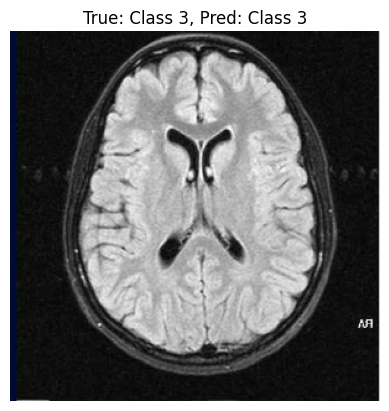

In [52]:
import matplotlib.pyplot as plt
import keras

loaded_model = keras.saving.load_model('cnn_finetuned.keras')


# Example list of class names (replace with your actual class names)
class_names = ["Class 1", "Class 2", "Class 3", "Class 4"]

# Get one batch from the dataset
for images, labels in train_ds.take(1):
    image = images[0:1]  # Select one image
    true_label = labels[0]  # Actual label (one-hot encoded)
    break

# Predict using the model
logits = loaded_model.predict(image)

# Apply softmax to convert logits to probabilities
probabilities = tf.nn.softmax(logits).numpy()[0]

# Get predicted class index and its probability
predicted_class_index = np.argmax(probabilities)
predicted_class_name = class_names[predicted_class_index]

# Get the actual class name (if labels are one-hot encoded, we need to find the index of the 1)
actual_class_index = np.argmax(true_label)
actual_class_name = class_names[true_label]

# Print results
print("Predicted Class:", predicted_class_name)
print("Predicted Class Score:", probabilities[true_label])
print("Actual Class:", actual_class_name)

# Display the image
plt.imshow(np.array(image[0]).astype("uint8"))
plt.title(f"True: {actual_class_name}, Pred: {predicted_class_name}")
plt.axis('off')  # Hide axis for better visualization
plt.show()
